###An Explainable Machine Learning and Deep Learning-Based Graduate Employability Prediction Prototype.

#Import Libraries

In [1]:
# I installed the LIME library so I could perform local model explanations.

!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# I used warnings to keep the notebook output clean.
import warnings
warnings.filterwarnings("ignore")

# I used joblib for saving and loading trained objects.
import joblib
# I used random and NumPy for numerical and reproducible operations.
import random
import numpy as np
# I used pandas for working with the dataset.
import pandas as pd

# I used Matplotlib and Seaborn for data visualisation.
import matplotlib.pyplot as plt
import seaborn as sns

# I used encoding and scaling tools to prepare the features.
from sklearn.preprocessing import LabelEncoder, StandardScaler
# I used these tools to split the data and tune the models.
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
)

# I used these metrics to evaluate and compare model performance.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.neural_network import MLPClassifier

# I used SMOTE to balance the training classes.
from imblearn.over_sampling import SMOTE

# I used SHAP and LIME to explain model predictions.
import shap
import lime
import lime.lime_tabular

import ipywidgets as widgets
from IPython.display import display, clear_output

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

#Load Dataset

In [3]:
# I loaded the graduate employability dataset.

df = pd.read_csv("dataset.csv")

display(df.head())

print("Dataset Shape :", df.shape)

,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector
0,Vietnam,Bachelor's,IT,Fluent,Permanent Residency,Female,Low,EU,23,8,3.76,Yes,Employed,54397,Healthcare
1,Germany,Master's,Arts,Intermediate,Post-study,Male,High,UK,38,9,3.76,No,Employed,69635,Finance
2,Brazil,PhD,Engineering,Intermediate,Post-study,Male,High,Canada,23,2,3.52,Yes,Employed,96216,Finance
3,Vietnam,PhD,Health,Fluent,Post-study,Female,Medium,Australia,25,5,3.28,Yes,Employed,86076,Other
4,Nigeria,PhD,Engineering,Basic,Student,Male,High,Canada,24,2,3.01,Yes,Employed,82772,Finance


Dataset Shape : (300000, 15)


#Basic Dataset Operations

In [4]:
# I examined the basic information of the dataset.

print("Dataset Information")
df.info()

print("\nDataset Shape :", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nSummary Statistics")
display(df.describe(include="all"))

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Country_of_Origin       300000 non-null  object 
 1   Education_Level         300000 non-null  object 
 2   Field_of_Study          300000 non-null  object 
 3   Language_Proficiency    300000 non-null  object 
 4   Visa_Type               300000 non-null  object 
 5   Gender                  300000 non-null  object 
 6   University_Ranking      300000 non-null  object 
 7   Region_of_Study         300000 non-null  object 
 8   Age                     300000 non-null  int64  
 9   Years_Since_Graduation  300000 non-null  int64  
 10  GPA                     300000 non-null  float64
 11  Internship_Experience   300000 non-null  object 
 12  Employment_Status       300000 non-null  object 
 13  Salary                  300000 non-null  int64  
 14  

,0
Country_of_Origin,object
Education_Level,object
Field_of_Study,object
Language_Proficiency,object
Visa_Type,object
Gender,object
University_Ranking,object
Region_of_Study,object
Age,int64
Years_Since_Graduation,int64



Summary Statistics


,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector
count,300000,300000,300000,300000,300000,300000,300000,300000,300000.000000,300000.000000,300000.000000,300000,300000,300000.000000,156644
unique,8,4,6,4,4,3,3,4,NaN,NaN,NaN,2,3,NaN,8
top,Brazil,Bachelor's,Arts,Intermediate,Student,Male,Medium,Australia,NaN,NaN,NaN,Yes,Employed,NaN,IT
freq,37751,120143,50144,90133,119754,143890,149847,75233,NaN,NaN,NaN,194710,156644,NaN,19716
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.495950,4.504150,3.200365,NaN,NaN,30333.692383,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.187951,2.874557,0.400285,NaN,NaN,31791.208938,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,0.000000,1.350000,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000,2.000000,2.930000,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,5.000000,3.200000,NaN,NaN,32296.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,7.000000,3.470000,NaN,NaN,56634.000000,NaN


#Data Preprocessing

In [5]:
# I created a copy of the original dataset.
df_processed = df.copy()

# I checked the missing values.
print("Missing Values Before Preprocessing:")
display(df_processed.isnull().sum())

# I replaced the missing values in Job_Sector.
df_processed["Job_Sector"] = df_processed["Job_Sector"].fillna("Unknown")

# I removed the remaining missing values.
df_processed.dropna(inplace=True)

# I verified the missing values.
print("\nMissing Values After Handling:")
display(df_processed.isnull().sum())

# I checked the duplicate records.
print("\nDuplicate Records Before Removal:", df_processed.duplicated().sum())

# I removed the duplicate records.
df_processed.drop_duplicates(inplace=True)

# I verified the duplicate removal.
print("Duplicate Records After Removal:", df_processed.duplicated().sum())

# I grouped the infrequent job sectors.
sector_counts = df_processed["Job_Sector"].value_counts()

rare_sectors = sector_counts[sector_counts < 100].index

df_processed["Job_Sector"] = df_processed["Job_Sector"].replace(
    rare_sectors,
    "Other"
)

# I reduced the skewness of Salary.
df_processed["Salary"] = np.log1p(df_processed["Salary"])

# I created the Academic Performance feature.
df_processed["Academic_Performance"] = (
    df_processed["GPA"] *
    (df_processed["Internship_Experience"].map({"Yes": 1, "No": 0}) + 1)
)

# I created the Graduate Maturity feature.
df_processed["Graduate_Maturity"] = (
    df_processed["Age"] -
    df_processed["Years_Since_Graduation"]
)

# I stored the categorical columns for Label Encoding.
label_columns = [
    "Language_Proficiency",
    "University_Ranking",
    "Internship_Experience",
    "Job_Sector"
]

label_encoders = {}

# I applied Label Encoding.
for column in label_columns:

    encoder = LabelEncoder()

    df_processed[column] = encoder.fit_transform(
        df_processed[column]
    )

    label_encoders[column] = encoder

# I encoded the target variable.
target_encoder = LabelEncoder()

df_processed["Employment_Status"] = target_encoder.fit_transform(
    df_processed["Employment_Status"]
)

label_encoders["Employment_Status"] = target_encoder

# I applied One-Hot Encoding.
df_processed = pd.get_dummies(
    df_processed,
    columns=[
        "Country_of_Origin",
        "Education_Level",
        "Field_of_Study",
        "Visa_Type",
        "Gender",
        "Region_of_Study"
    ],
    drop_first=True,
    dtype=int
)

# I identified the numerical columns.
numerical_columns = df_processed.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_columns.remove("Employment_Status")

# I treated the outliers using the IQR method.
for column in numerical_columns:

    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df_processed[column] = df_processed[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

# I displayed the processed dataset.
display(df_processed.head())

print("\nPreprocessed Dataset Shape:", df_processed.shape)

Missing Values Before Preprocessing:


,0
Country_of_Origin,0
Education_Level,0
Field_of_Study,0
Language_Proficiency,0
Visa_Type,0
Gender,0
University_Ranking,0
Region_of_Study,0
Age,0
Years_Since_Graduation,0



Missing Values After Handling:


,0
Country_of_Origin,0
Education_Level,0
Field_of_Study,0
Language_Proficiency,0
Visa_Type,0
Gender,0
University_Ranking,0
Region_of_Study,0
Age,0
Years_Since_Graduation,0



Duplicate Records Before Removal: 3
Duplicate Records After Removal: 0


,Language_Proficiency,University_Ranking,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector,Academic_Performance,Graduate_Maturity,Country_of_Origin_China,Country_of_Origin_Germany,Country_of_Origin_India,Country_of_Origin_Nigeria,Country_of_Origin_Pakistan,Country_of_Origin_USA,Country_of_Origin_Vietnam,Education_Level_Diploma,Education_Level_Master's,Education_Level_PhD,Field_of_Study_Business,Field_of_Study_Engineering,Field_of_Study_Health,Field_of_Study_IT,Field_of_Study_Social Sciences,Visa_Type_Post-study,Visa_Type_Student,Visa_Type_Work Visa,Gender_Male,Gender_Other,Region_of_Study_Canada,Region_of_Study_EU,Region_of_Study_UK
0,2,1,23,8,3.76,1,1,10.904083,4,7.52,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,3,0,38,9,3.76,0,1,11.151037,3,3.76,29,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0
2,3,0,23,2,3.52,1,1,11.474361,3,7.04,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
3,2,2,25,5,3.28,1,1,11.362998,6,6.56,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,1,0,24,2,3.01,1,1,11.323857,3,6.02,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0



Preprocessed Dataset Shape: (299997, 34)


#Exploratory Data Analysis (EDA)

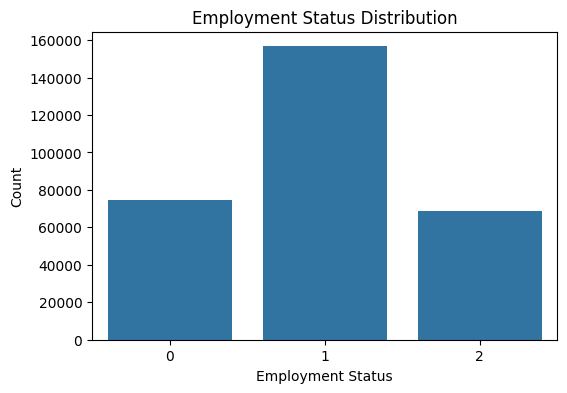

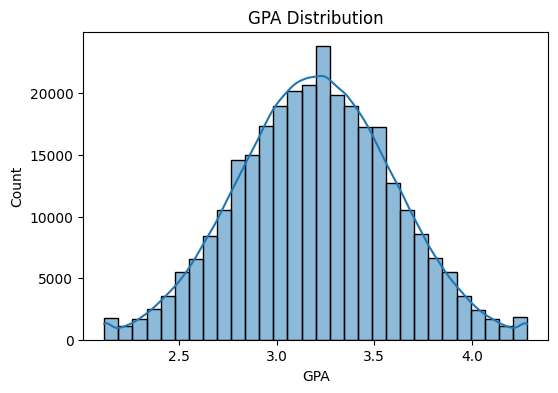

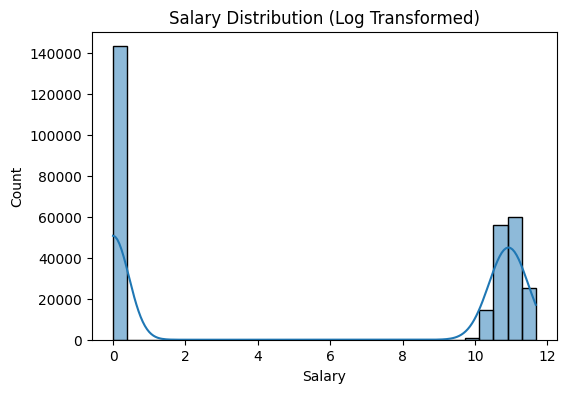

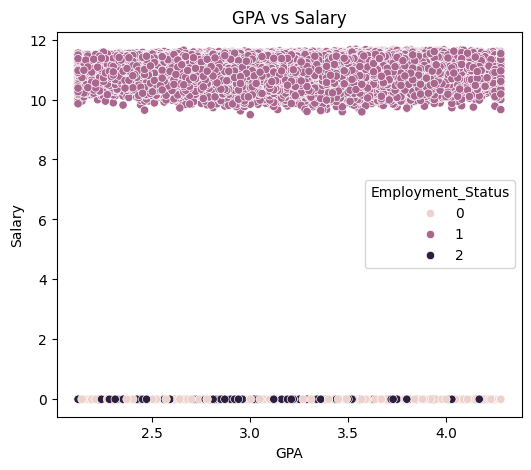

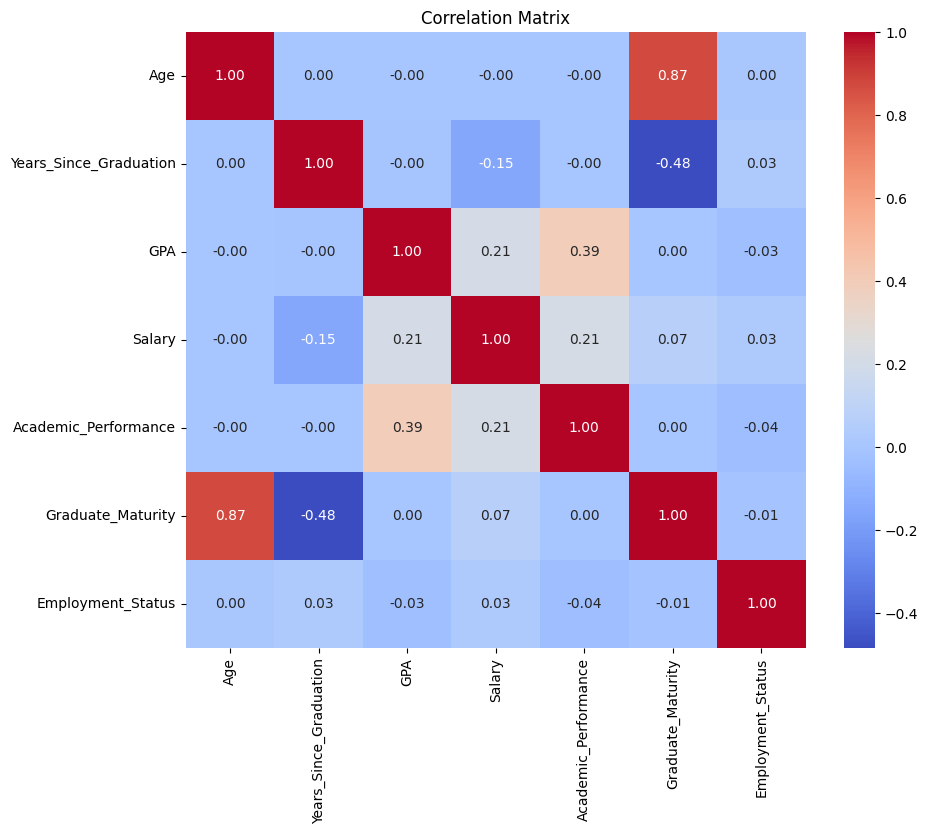

In [6]:
# I explored the characteristics of the processed dataset.

# I displayed the class distribution.
plt.figure(figsize=(6,4))

sns.countplot(
    x="Employment_Status",
    data=df_processed
)

plt.title("Employment Status Distribution")
plt.xlabel("Employment Status")
plt.ylabel("Count")

plt.show()


# I displayed the GPA distribution.
plt.figure(figsize=(6,4))

sns.histplot(
    df_processed["GPA"],
    bins=30,
    kde=True
)

plt.title("GPA Distribution")

plt.show()


# I examined the Salary distribution.
plt.figure(figsize=(6,4))

sns.histplot(
    df_processed["Salary"],
    bins=30,
    kde=True
)

plt.title("Salary Distribution (Log Transformed)")

plt.show()


# I examined the relationship between GPA and Salary.
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df_processed,
    x="GPA",
    y="Salary",
    hue="Employment_Status"
)

plt.title("GPA vs Salary")

plt.show()


# I examined the correlation among numerical features.
plt.figure(figsize=(10,8))

corr = df_processed[
    [
        "Age",
        "Years_Since_Graduation",
        "GPA",
        "Salary",
        "Academic_Performance",
        "Graduate_Maturity",
        "Employment_Status"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#Train-Test Split

In [7]:
# I separated the features and target variable.

X = df_processed.drop(columns=["Employment_Status"])
y = df_processed["Employment_Status"]

# I split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (239997, 33)
Testing Set  : (60000, 33)


#Feature Scaling

In [8]:
# I standardized the numerical features.

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (239997, 33)
Testing Data Shape  : (60000, 33)


#Model Evaluation Function

In [10]:
# I created a function to evaluate the model performance.

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.show()

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

#Original Dataset Models Training

# Logistic Regression

Accuracy  : 0.8044
Precision : 0.8040
Recall    : 0.8044
F1-Score  : 0.8040
ROC-AUC   : 0.9449

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.63      0.62     14923
           1       1.00      1.00      1.00     31329
           2       0.58      0.54      0.56     13748

    accuracy                           0.80     60000
   macro avg       0.73      0.73      0.73     60000
weighted avg       0.80      0.80      0.80     60000



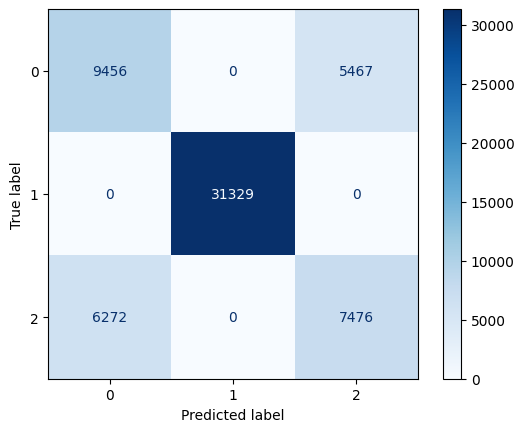

In [11]:
# I initialized the Logistic Regression model.
log_original = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# I trained the Logistic Regression model using the original training data.
log_original.fit(X_train_scaled, y_train)

# I evaluated the Logistic Regression model using the test data.
log_original_results = evaluate_model(
    log_original,
    X_test_scaled,
    y_test
)


# XGBoost

Accuracy  : 0.8198
Precision : 0.8198
Recall    : 0.8198
F1-Score  : 0.8198
ROC-AUC   : 0.9528

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.64      0.64     14923
           1       1.00      1.00      1.00     31329
           2       0.61      0.61      0.61     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



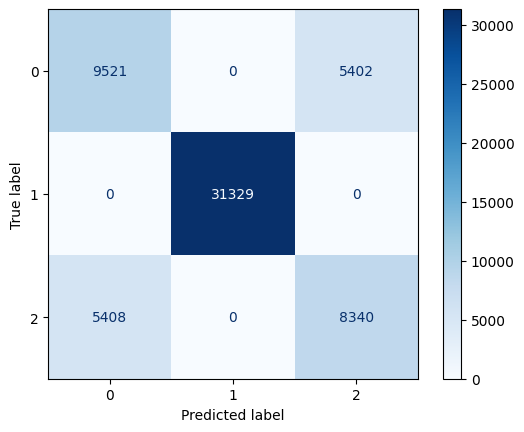

In [12]:
# I initialized the XGBoost model.
xgb_original = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE
)

# I trained the XGBoost model using the original training data.
xgb_original.fit(X_train_scaled, y_train)

# I evaluated the XGBoost model using the test data.
xgb_original_results = evaluate_model(
    xgb_original,
    X_test_scaled,
    y_test
)


# LightGBM

Accuracy  : 0.8224
Precision : 0.8223
Recall    : 0.8224
F1-Score  : 0.8215
ROC-AUC   : 0.9533

Classification Report

              precision    recall  f1-score   support

           0       0.63      0.69      0.66     14923
           1       1.00      1.00      1.00     31329
           2       0.63      0.56      0.59     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



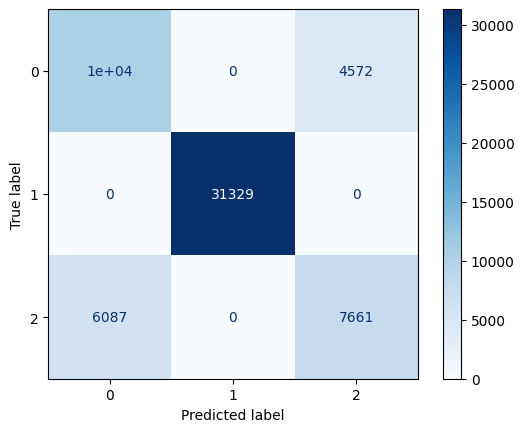

In [13]:
# I initialized the LightGBM model.
lgbm_original = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1,
    force_col_wise=True
)

# I trained the LightGBM model using the original training data.
lgbm_original.fit(X_train_scaled, y_train)

# I evaluated the LightGBM model using the test data.
lgbm_original_results = evaluate_model(
    lgbm_original,
    X_test_scaled,
    y_test
)


# Artificial Neural Network

Accuracy  : 0.8196
Precision : 0.8195
Recall    : 0.8196
F1-Score  : 0.8196
ROC-AUC   : 0.9527


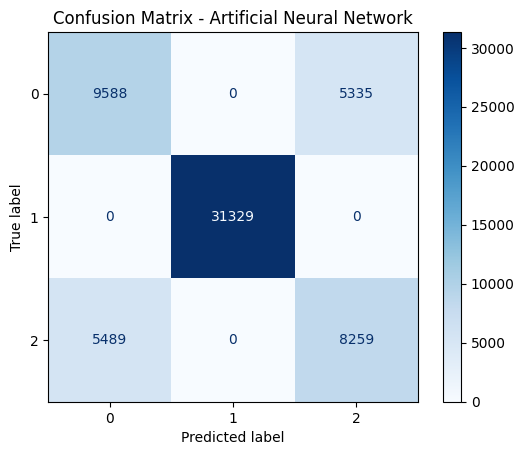

In [14]:
# I initialized the Artificial Neural Network.
ann_original = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=RANDOM_STATE
)

# I trained the Artificial Neural Network using the original training data.
ann_original.fit(X_train_scaled, y_train)

# I predicted the test labels using the Artificial Neural Network.
y_pred = ann_original.predict(X_test_scaled)

# I predicted the class probabilities using the Artificial Neural Network.
y_prob = ann_original.predict_proba(X_test_scaled)

# I calculated the evaluation metrics for the Artificial Neural Network.
ann_original_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted"),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )
}

# I displayed the Artificial Neural Network performance.
print("Accuracy  :", f"{ann_original_results['Accuracy']:.4f}")
print("Precision :", f"{ann_original_results['Precision']:.4f}")
print("Recall    :", f"{ann_original_results['Recall']:.4f}")
print("F1-Score  :", f"{ann_original_results['F1-Score']:.4f}")
print("ROC-AUC   :", f"{ann_original_results['ROC-AUC']:.4f}")

# I displayed the confusion matrix for the Artificial Neural Network.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)
plt.title("Confusion Matrix - Artificial Neural Network")
plt.show()


# Original Dataset Model Comparison

In [15]:
# I created a comparison table for the four models trained on the original dataset.
original_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        log_original_results["Accuracy"],
        xgb_original_results["Accuracy"],
        lgbm_original_results["Accuracy"],
        ann_original_results["Accuracy"]
    ],
    "Precision": [
        log_original_results["Precision"],
        xgb_original_results["Precision"],
        lgbm_original_results["Precision"],
        ann_original_results["Precision"]
    ],
    "Recall": [
        log_original_results["Recall"],
        xgb_original_results["Recall"],
        lgbm_original_results["Recall"],
        ann_original_results["Recall"]
    ],
    "F1-Score": [
        log_original_results["F1-Score"],
        xgb_original_results["F1-Score"],
        lgbm_original_results["F1-Score"],
        ann_original_results["F1-Score"]
    ],
    "ROC-AUC": [
        log_original_results["ROC-AUC"],
        xgb_original_results["ROC-AUC"],
        lgbm_original_results["ROC-AUC"],
        ann_original_results["ROC-AUC"]
    ]
})

# I rounded the comparison values to four decimal places.
original_results = original_results.round(4)

# I displayed the original dataset model comparison.
display(original_results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8044,0.8040,0.8044,0.8040,0.9449
1,XGBoost,0.8198,0.8198,0.8198,0.8198,0.9528
2,LightGBM,0.8224,0.8223,0.8224,0.8215,0.9533
3,Artificial Neural Network,0.8196,0.8195,0.8196,0.8196,0.9527


#SMOTE

In [16]:
# I balanced the training dataset using SMOTE.

smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

print("\nBalanced Training Shape :", X_train_smote.shape)


Before SMOTE
Employment_Status
1    125315
0     59692
2     54990
Name: count, dtype: int64

After SMOTE
Employment_Status
0    125315
1    125315
2    125315
Name: count, dtype: int64

Balanced Training Shape : (375945, 33)


# Logistic Regression with SMOTE

Accuracy  : 0.8044
Precision : 0.8052
Recall    : 0.8044
F1-Score  : 0.8044
ROC-AUC   : 0.9449

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.57      0.59     14923
           1       1.00      1.00      1.00     31329
           2       0.57      0.61      0.59     13748

    accuracy                           0.80     60000
   macro avg       0.73      0.73      0.73     60000
weighted avg       0.81      0.80      0.80     60000



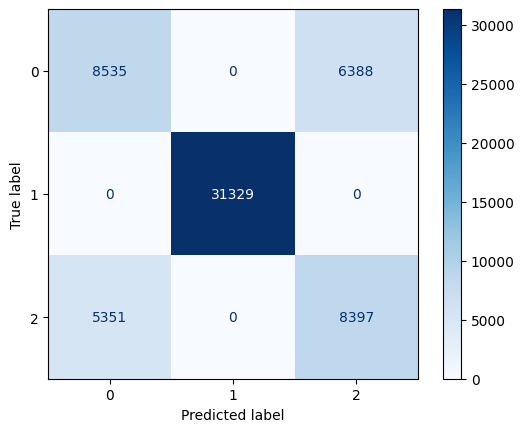

In [17]:
# I initialized the Logistic Regression model for the SMOTE training data.
log_smote = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

# I trained the Logistic Regression model using the SMOTE training data.
log_smote.fit(X_train_smote, y_train_smote)

# I evaluated the Logistic Regression model using the test data.
log_smote_results = evaluate_model(
    log_smote,
    X_test_scaled,
    y_test
)


# XGBoost with SMOTE

Accuracy  : 0.8171
Precision : 0.8190
Recall    : 0.8171
F1-Score  : 0.8169
ROC-AUC   : 0.9526

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.57      0.61     14923
           1       1.00      1.00      1.00     31329
           2       0.59      0.67      0.63     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.74     60000
weighted avg       0.82      0.82      0.82     60000



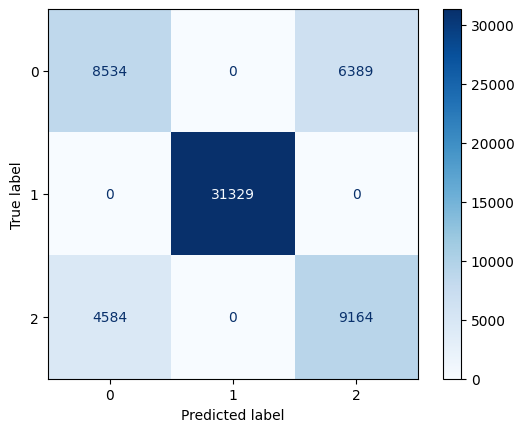

In [18]:
# I initialized the XGBoost model for the SMOTE training data.
xgb_smote = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE
)

# I trained the XGBoost model using the SMOTE training data.
xgb_smote.fit(X_train_smote, y_train_smote)

# I evaluated the XGBoost model using the test data.
xgb_smote_results = evaluate_model(
    xgb_smote,
    X_test_scaled,
    y_test
)


# LightGBM with SMOTE

Accuracy  : 0.8173
Precision : 0.8205
Recall    : 0.8173
F1-Score  : 0.8164
ROC-AUC   : 0.9531

Classification Report

              precision    recall  f1-score   support

           0       0.66      0.55      0.60     14923
           1       1.00      1.00      1.00     31329
           2       0.59      0.70      0.64     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.74     60000
weighted avg       0.82      0.82      0.82     60000



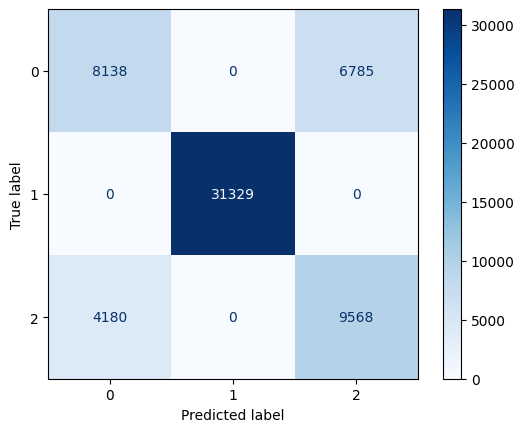

In [19]:
# I initialized the LightGBM model for the SMOTE training data.
lgbm_smote = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1,
    force_col_wise=True
)

# I trained the LightGBM model using the SMOTE training data.
lgbm_smote.fit(X_train_smote, y_train_smote)

# I evaluated the LightGBM model using the test data.
lgbm_smote_results = evaluate_model(
    lgbm_smote,
    X_test_scaled,
    y_test
)


# Artificial Neural Network with SMOTE

Accuracy  : 0.8167
Precision : 0.8212
Recall    : 0.8167
F1-Score  : 0.8152
ROC-AUC   : 0.9520


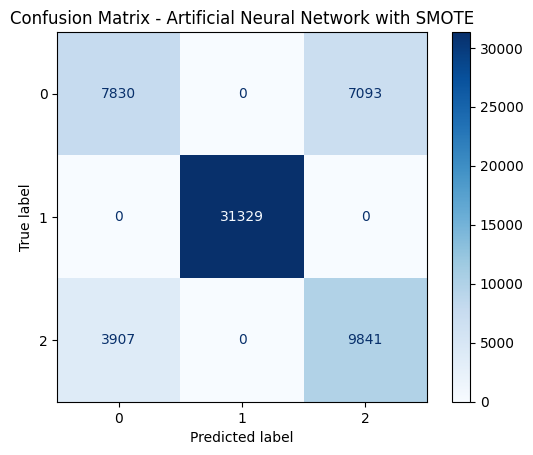

In [20]:
# I initialized the Artificial Neural Network for the SMOTE training data.
ann_smote = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=RANDOM_STATE
)

# I trained the Artificial Neural Network using the SMOTE training data.
ann_smote.fit(X_train_smote, y_train_smote)

# I predicted the test labels using the Artificial Neural Network.
y_pred = ann_smote.predict(X_test_scaled)

# I predicted the class probabilities using the Artificial Neural Network.
y_prob = ann_smote.predict_proba(X_test_scaled)

# I calculated the evaluation metrics for the Artificial Neural Network.
ann_smote_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted"),
    "Recall": recall_score(y_test, y_pred, average="weighted"),
    "F1-Score": f1_score(y_test, y_pred, average="weighted"),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )
}

# I displayed the Artificial Neural Network performance.
print("Accuracy  :", f"{ann_smote_results['Accuracy']:.4f}")
print("Precision :", f"{ann_smote_results['Precision']:.4f}")
print("Recall    :", f"{ann_smote_results['Recall']:.4f}")
print("F1-Score  :", f"{ann_smote_results['F1-Score']:.4f}")
print("ROC-AUC   :", f"{ann_smote_results['ROC-AUC']:.4f}")

# I displayed the confusion matrix for the Artificial Neural Network.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)
plt.title("Confusion Matrix - Artificial Neural Network with SMOTE")
plt.show()


# SMOTE Model Comparison

In [21]:
# I created a comparison table for the four models trained on the SMOTE dataset.
smote_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        log_smote_results["Accuracy"],
        xgb_smote_results["Accuracy"],
        lgbm_smote_results["Accuracy"],
        ann_smote_results["Accuracy"]
    ],
    "Precision": [
        log_smote_results["Precision"],
        xgb_smote_results["Precision"],
        lgbm_smote_results["Precision"],
        ann_smote_results["Precision"]
    ],
    "Recall": [
        log_smote_results["Recall"],
        xgb_smote_results["Recall"],
        lgbm_smote_results["Recall"],
        ann_smote_results["Recall"]
    ],
    "F1-Score": [
        log_smote_results["F1-Score"],
        xgb_smote_results["F1-Score"],
        lgbm_smote_results["F1-Score"],
        ann_smote_results["F1-Score"]
    ],
    "ROC-AUC": [
        log_smote_results["ROC-AUC"],
        xgb_smote_results["ROC-AUC"],
        lgbm_smote_results["ROC-AUC"],
        ann_smote_results["ROC-AUC"]
    ]
})

# I rounded the comparison values to four decimal places.
smote_results = smote_results.round(4)

# I displayed the SMOTE model comparison.
display(smote_results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8044,0.8052,0.8044,0.8044,0.9449
1,XGBoost,0.8171,0.8190,0.8171,0.8169,0.9526
2,LightGBM,0.8172,0.8205,0.8172,0.8164,0.9531
3,Artificial Neural Network,0.8167,0.8212,0.8167,0.8152,0.9520


#Hyperparameter Tuning

#GridSearchCV

# Logistic Regression with GridSearchCV

Logistic Regression: {'C': 0.1}
Accuracy  : 0.8044
Precision : 0.8051
Recall    : 0.8044
F1-Score  : 0.8044
ROC-AUC   : 0.9449

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.57      0.59     14923
           1       1.00      1.00      1.00     31329
           2       0.57      0.61      0.59     13748

    accuracy                           0.80     60000
   macro avg       0.73      0.73      0.73     60000
weighted avg       0.81      0.80      0.80     60000



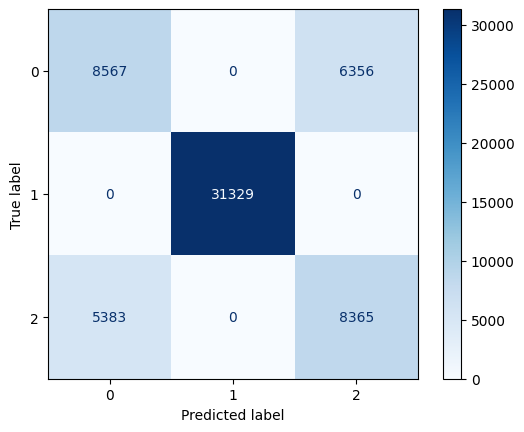

In [22]:
# I created the Logistic Regression parameter grid.
log_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    {"C": [0.1, 1, 10]},
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

# I fitted GridSearchCV using the SMOTE training data.
log_grid.fit(X_train_smote, y_train_smote)

# I displayed the best Logistic Regression parameters.
print("Logistic Regression:", log_grid.best_params_)

# I evaluated the best Logistic Regression model.
grid_log_results = evaluate_model(
    log_grid.best_estimator_,
    X_test_scaled,
    y_test
)


# XGBoost with GridSearchCV

XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Accuracy  : 0.8192
Precision : 0.8198
Recall    : 0.8192
F1-Score  : 0.8192
ROC-AUC   : 0.9531

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.61      0.63     14923
           1       1.00      1.00      1.00     31329
           2       0.60      0.64      0.62     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



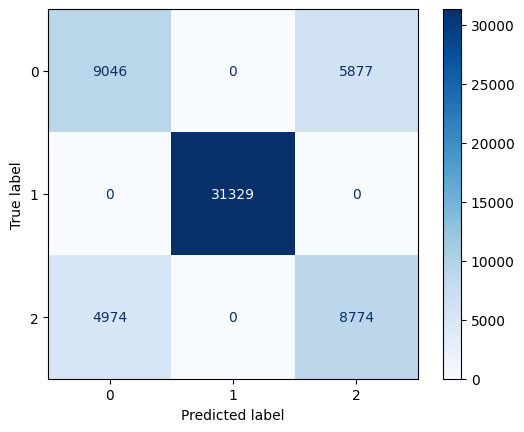

In [23]:
# I created the XGBoost parameter grid.
xgb_grid = GridSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y)),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ),
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

# I fitted GridSearchCV using the SMOTE training data.
xgb_grid.fit(X_train_smote, y_train_smote)

# I displayed the best XGBoost parameters.
print("XGBoost:", xgb_grid.best_params_)

# I evaluated the best XGBoost model.
grid_xgb_results = evaluate_model(
    xgb_grid.best_estimator_,
    X_test_scaled,
    y_test
)


# LightGBM with GridSearchCV

LightGBM: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Accuracy  : 0.8204
Precision : 0.8211
Recall    : 0.8204
F1-Score  : 0.8204
ROC-AUC   : 0.9532

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.61      0.63     14923
           1       1.00      1.00      1.00     31329
           2       0.60      0.64      0.62     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



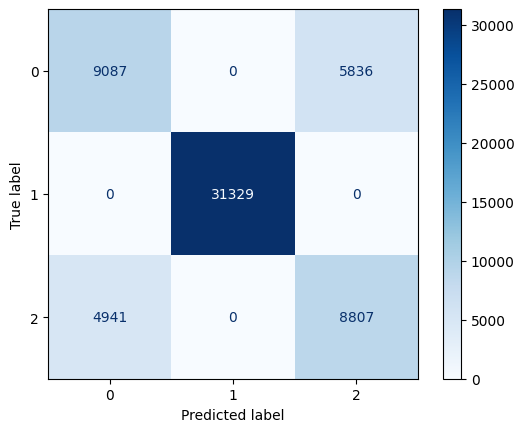

In [24]:
# I created the LightGBM parameter grid.
lgbm_grid = GridSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
        force_col_wise=True
    ),
    {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

# I fitted GridSearchCV using the SMOTE training data.
lgbm_grid.fit(X_train_smote, y_train_smote)

# I displayed the best LightGBM parameters.
print("LightGBM:", lgbm_grid.best_params_)

# I evaluated the best LightGBM model.
grid_lgbm_results = evaluate_model(
    lgbm_grid.best_estimator_,
    X_test_scaled,
    y_test
)


# Artificial Neural Network with GridSearchCV

Artificial Neural Network: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Accuracy  : 0.8193
Precision : 0.8208
Recall    : 0.8193
F1-Score  : 0.8191
ROC-AUC   : 0.9523

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.58      0.62     14923
           1       1.00      1.00      1.00     31329
           2       0.59      0.66      0.63     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



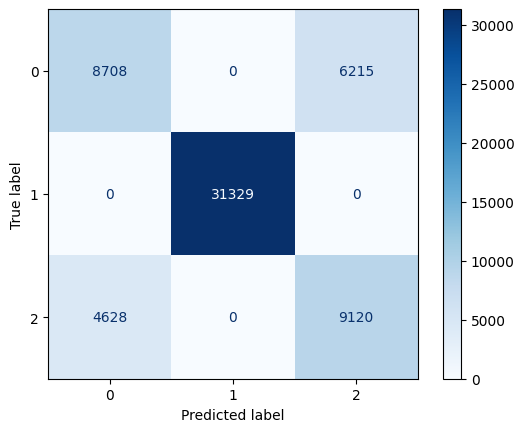

In [26]:
# I created the Artificial Neural Network parameter grid.
ann_grid = GridSearchCV(
    MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=100,
        random_state=RANDOM_STATE
    ),
    {
        "hidden_layer_sizes": [(64,), (64, 32)],
        "alpha": [0.0001, 0.001],
        "learning_rate_init": [0.001, 0.01]
    },
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

# I fitted GridSearchCV using the SMOTE training data.
ann_grid.fit(X_train_smote, y_train_smote)

# I displayed the best Artificial Neural Network parameters.
print("Artificial Neural Network:", ann_grid.best_params_)

# I evaluated the best Artificial Neural Network model.
grid_ann_results = evaluate_model(
    ann_grid.best_estimator_,
    X_test_scaled,
    y_test
)


# GridSearchCV Model Comparison

In [27]:
# I created a comparison table for the four GridSearchCV models.
grid_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Artificial Neural Network"
    ],
    "Accuracy": [r["Accuracy"] for r in [grid_log_results, grid_xgb_results, grid_lgbm_results, grid_ann_results]],
    "Precision": [r["Precision"] for r in [grid_log_results, grid_xgb_results, grid_lgbm_results, grid_ann_results]],
    "Recall": [r["Recall"] for r in [grid_log_results, grid_xgb_results, grid_lgbm_results, grid_ann_results]],
    "F1-Score": [r["F1-Score"] for r in [grid_log_results, grid_xgb_results, grid_lgbm_results, grid_ann_results]],
    "ROC-AUC": [r["ROC-AUC"] for r in [grid_log_results, grid_xgb_results, grid_lgbm_results, grid_ann_results]]
})

# I rounded the comparison values to four decimal places.
grid_results = grid_results.round(4)

# I displayed the GridSearchCV model comparison.
display(grid_results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8044,0.8051,0.8044,0.8044,0.9449
1,XGBoost,0.8192,0.8198,0.8192,0.8192,0.9531
2,LightGBM,0.8204,0.8211,0.8204,0.8204,0.9532
3,Artificial Neural Network,0.8193,0.8208,0.8193,0.8191,0.9523


#RandomizedSearchCV

# Logistic Regression with RandomizedSearchCV

Logistic Regression: {'C': 0.1}
Accuracy  : 0.8044
Precision : 0.8051
Recall    : 0.8044
F1-Score  : 0.8044
ROC-AUC   : 0.9449

Classification Report

              precision    recall  f1-score   support

           0       0.61      0.57      0.59     14923
           1       1.00      1.00      1.00     31329
           2       0.57      0.61      0.59     13748

    accuracy                           0.80     60000
   macro avg       0.73      0.73      0.73     60000
weighted avg       0.81      0.80      0.80     60000



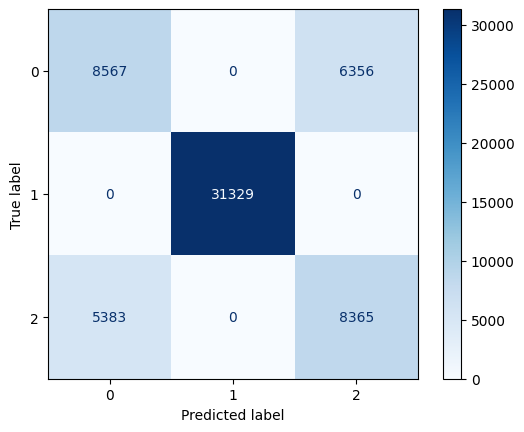

In [28]:
# I created the Logistic Regression parameter distribution.
log_random = RandomizedSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    {"C": [0.1, 1, 10]},
    n_iter=3,
    scoring="f1_weighted",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# I fitted RandomizedSearchCV using the SMOTE training data.
log_random.fit(X_train_smote, y_train_smote)

# I displayed the best Logistic Regression parameters.
print("Logistic Regression:", log_random.best_params_)

# I evaluated the best Logistic Regression model.
random_log_results = evaluate_model(
    log_random.best_estimator_,
    X_test_scaled,
    y_test
)


# XGBoost with RandomizedSearchCV

XGBoost: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Accuracy  : 0.8198
Precision : 0.8199
Recall    : 0.8198
F1-Score  : 0.8199
ROC-AUC   : 0.9530

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.63      0.63     14923
           1       1.00      1.00      1.00     31329
           2       0.60      0.62      0.61     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



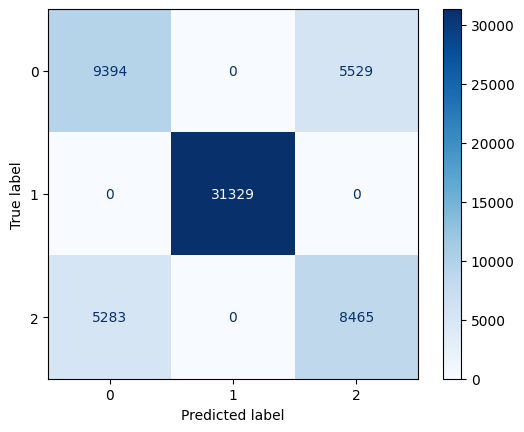

In [29]:
# I created the XGBoost parameter distributions.
xgb_random = RandomizedSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y)),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ),
    {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# I fitted RandomizedSearchCV using the SMOTE training data.
xgb_random.fit(X_train_smote, y_train_smote)

# I displayed the best XGBoost parameters.
print("XGBoost:", xgb_random.best_params_)

# I evaluated the best XGBoost model.
random_xgb_results = evaluate_model(
    xgb_random.best_estimator_,
    X_test_scaled,
    y_test
)


# LightGBM with RandomizedSearchCV

LightGBM: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Accuracy  : 0.8201
Precision : 0.8206
Recall    : 0.8201
F1-Score  : 0.8201
ROC-AUC   : 0.9530

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.61      0.63     14923
           1       1.00      1.00      1.00     31329
           2       0.60      0.63      0.62     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.82      0.82      0.82     60000



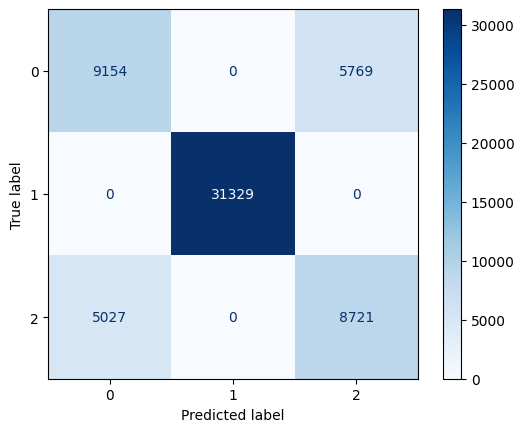

In [30]:
# I created the LightGBM parameter distributions.
lgbm_random = RandomizedSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1,
        force_col_wise=True
    ),
    {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# I fitted RandomizedSearchCV using the SMOTE training data.
lgbm_random.fit(X_train_smote, y_train_smote)

# I displayed the best LightGBM parameters.
print("LightGBM:", lgbm_random.best_params_)

# I evaluated the best LightGBM model.
random_lgbm_results = evaluate_model(
    lgbm_random.best_estimator_,
    X_test_scaled,
    y_test
)


# Artificial Neural Network with RandomizedSearchCV

Artificial Neural Network: {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (128, 64), 'alpha': 0.001}
Accuracy  : 0.8152
Precision : 0.8188
Recall    : 0.8152
F1-Score  : 0.8142
ROC-AUC   : 0.9501

Classification Report

              precision    recall  f1-score   support

           0       0.66      0.54      0.59     14923
           1       1.00      1.00      1.00     31329
           2       0.58      0.70      0.63     13748

    accuracy                           0.82     60000
   macro avg       0.75      0.74      0.74     60000
weighted avg       0.82      0.82      0.81     60000



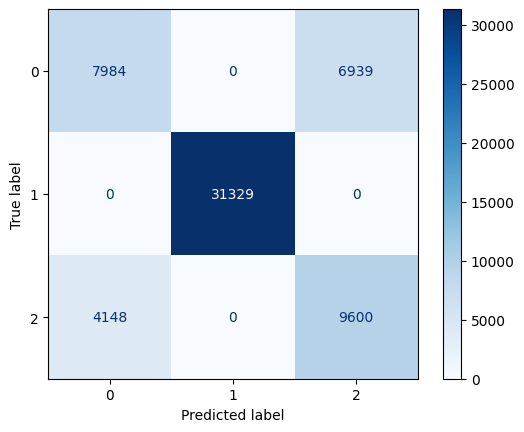

In [31]:
# I created the Artificial Neural Network parameter distributions.
ann_random = RandomizedSearchCV(
    MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=100,
        random_state=RANDOM_STATE
    ),
    {
        "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.0005, 0.001, 0.01]
    },
    n_iter=10,
    scoring="f1_weighted",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# I fitted RandomizedSearchCV using the SMOTE training data.
ann_random.fit(X_train_smote, y_train_smote)

# I displayed the best Artificial Neural Network parameters.
print("Artificial Neural Network:", ann_random.best_params_)

# I evaluated the best Artificial Neural Network model.
random_ann_results = evaluate_model(
    ann_random.best_estimator_,
    X_test_scaled,
    y_test
)


# RandomizedSearchCV Model Comparison

In [32]:
# I created a comparison table for the four RandomizedSearchCV models.
random_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "LightGBM",
        "Artificial Neural Network"
    ],
    "Accuracy": [r["Accuracy"] for r in [random_log_results, random_xgb_results, random_lgbm_results, random_ann_results]],
    "Precision": [r["Precision"] for r in [random_log_results, random_xgb_results, random_lgbm_results, random_ann_results]],
    "Recall": [r["Recall"] for r in [random_log_results, random_xgb_results, random_lgbm_results, random_ann_results]],
    "F1-Score": [r["F1-Score"] for r in [random_log_results, random_xgb_results, random_lgbm_results, random_ann_results]],
    "ROC-AUC": [r["ROC-AUC"] for r in [random_log_results, random_xgb_results, random_lgbm_results, random_ann_results]]
})

# I rounded the comparison values to four decimal places.
random_results = random_results.round(4)

# I displayed the RandomizedSearchCV model comparison.
display(random_results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8044,0.8051,0.8044,0.8044,0.9449
1,XGBoost,0.8198,0.8199,0.8198,0.8199,0.9530
2,LightGBM,0.8201,0.8206,0.8201,0.8201,0.9530
3,Artificial Neural Network,0.8152,0.8188,0.8152,0.8142,0.9501


# Final Model Comparison

In [33]:
# I combined the results from the original dataset, SMOTE, GridSearchCV, and RandomizedSearchCV.
# I added the training method to each result so I could identify where each score came from.
# I compared all four models across all four training approaches.
# I sorted the combined results by F1 Score so I could identify the strongest overall result.
# I displayed the final comparison table.

original_compare = original_results.copy()
original_compare.insert(0, "Method", "Original Data")

smote_compare = smote_results.copy()
smote_compare.insert(0, "Method", "SMOTE")

grid_compare = grid_results.copy()
grid_compare.insert(0, "Method", "GridSearchCV")

random_compare = random_results.copy()
random_compare.insert(0, "Method", "RandomizedSearchCV")

final_comparison = pd.concat(
    [original_compare, smote_compare, grid_compare, random_compare],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

final_comparison = final_comparison.round(4)

display(final_comparison)

,Method,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original Data,LightGBM,0.8224,0.8223,0.8224,0.8215,0.9533
1,GridSearchCV,LightGBM,0.8204,0.8211,0.8204,0.8204,0.9532
2,RandomizedSearchCV,LightGBM,0.8201,0.8206,0.8201,0.8201,0.9530
3,RandomizedSearchCV,XGBoost,0.8198,0.8199,0.8198,0.8199,0.9530
4,Original Data,XGBoost,0.8198,0.8198,0.8198,0.8198,0.9528
5,Original Data,Artificial Neural Network,0.8196,0.8195,0.8196,0.8196,0.9527
6,GridSearchCV,XGBoost,0.8192,0.8198,0.8192,0.8192,0.9531
7,GridSearchCV,Artificial Neural Network,0.8193,0.8208,0.8193,0.8191,0.9523
8,SMOTE,XGBoost,0.8171,0.8190,0.8171,0.8169,0.9526
9,SMOTE,LightGBM,0.8172,0.8205,0.8172,0.8164,0.9531


#Best Model Selection

In [34]:
# I selected the best model and training approach based on the highest F1 Score.
# I identified the model name and training method from the best result.
# I matched the selected result with its trained model object.
# I stored the final selected model for the explainability and prototype stages.

best_row = final_comparison.iloc[0]

best_model_name = best_row["Model"]
best_method = best_row["Method"]

model_objects = {
    ("Original Data", "Logistic Regression"): log_original,
    ("Original Data", "XGBoost"): xgb_original,
    ("Original Data", "LightGBM"): lgbm_original,
    ("Original Data", "Artificial Neural Network"): ann_original,
    ("SMOTE", "Logistic Regression"): log_smote,
    ("SMOTE", "XGBoost"): xgb_smote,
    ("SMOTE", "LightGBM"): lgbm_smote,
    ("SMOTE", "Artificial Neural Network"): ann_smote,
    ("GridSearchCV", "Logistic Regression"): log_grid.best_estimator_,
    ("GridSearchCV", "XGBoost"): xgb_grid.best_estimator_,
    ("GridSearchCV", "LightGBM"): lgbm_grid.best_estimator_,
    ("GridSearchCV", "Artificial Neural Network"): ann_grid.best_estimator_,
    ("RandomizedSearchCV", "Logistic Regression"): log_random.best_estimator_,
    ("RandomizedSearchCV", "XGBoost"): xgb_random.best_estimator_,
    ("RandomizedSearchCV", "LightGBM"): lgbm_random.best_estimator_,
    ("RandomizedSearchCV", "Artificial Neural Network"): ann_random.best_estimator_
}

best_model = model_objects[(best_method, best_model_name)]

print("Best Model   :", best_model_name)
print("Best Method  :", best_method)
print("F1-Score     :", f"{best_row['F1-Score']:.4f}")

# I kept the final model in best_lgbm for the existing SHAP, LIME and prototype cells.
best_lgbm = best_model
best_model_results = final_comparison.copy()

display(best_model_results)

Best Model   : LightGBM
Best Method  : Original Data
F1-Score     : 0.8215


,Method,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Original Data,LightGBM,0.8224,0.8223,0.8224,0.8215,0.9533
1,GridSearchCV,LightGBM,0.8204,0.8211,0.8204,0.8204,0.9532
2,RandomizedSearchCV,LightGBM,0.8201,0.8206,0.8201,0.8201,0.9530
3,RandomizedSearchCV,XGBoost,0.8198,0.8199,0.8198,0.8199,0.9530
4,Original Data,XGBoost,0.8198,0.8198,0.8198,0.8198,0.9528
5,Original Data,Artificial Neural Network,0.8196,0.8195,0.8196,0.8196,0.9527
6,GridSearchCV,XGBoost,0.8192,0.8198,0.8192,0.8192,0.9531
7,GridSearchCV,Artificial Neural Network,0.8193,0.8208,0.8193,0.8191,0.9523
8,SMOTE,XGBoost,0.8171,0.8190,0.8171,0.8169,0.9526
9,SMOTE,LightGBM,0.8172,0.8205,0.8172,0.8164,0.9531


#Comparision Graph

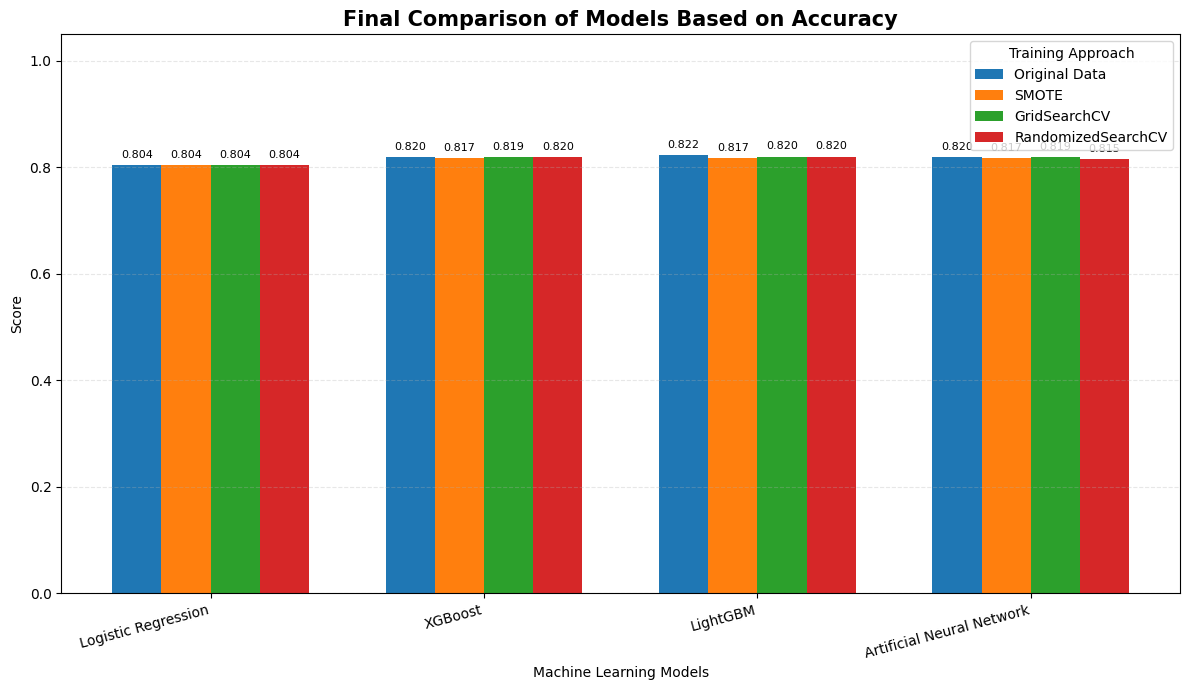

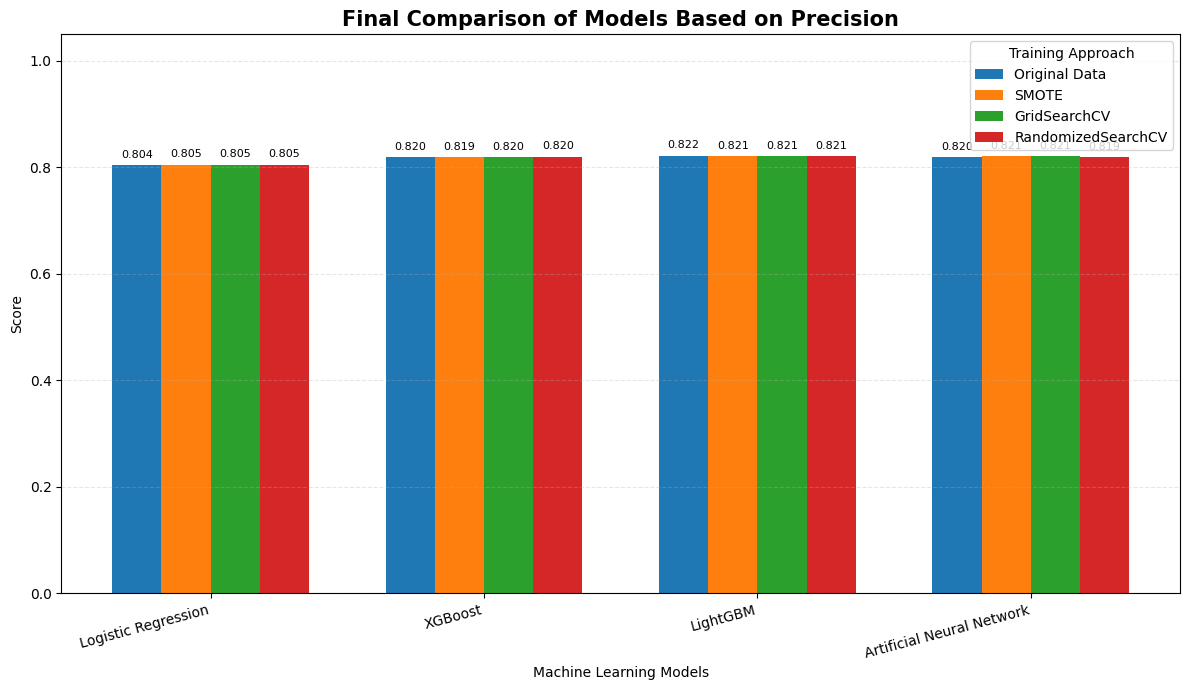

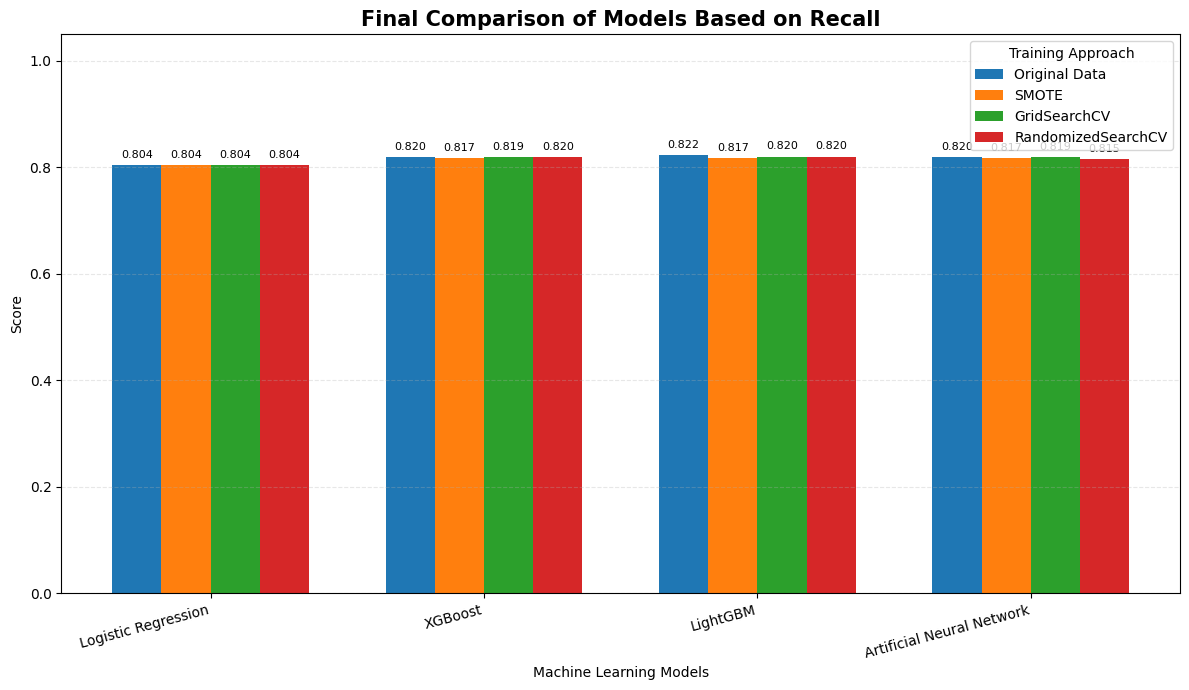

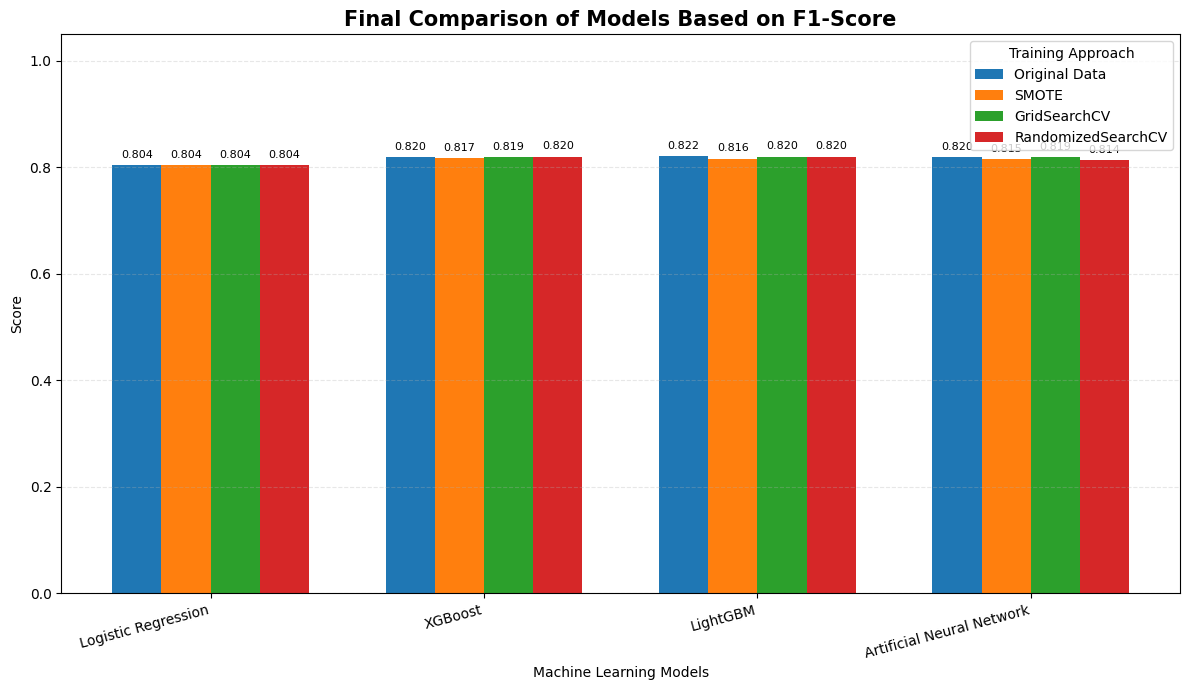

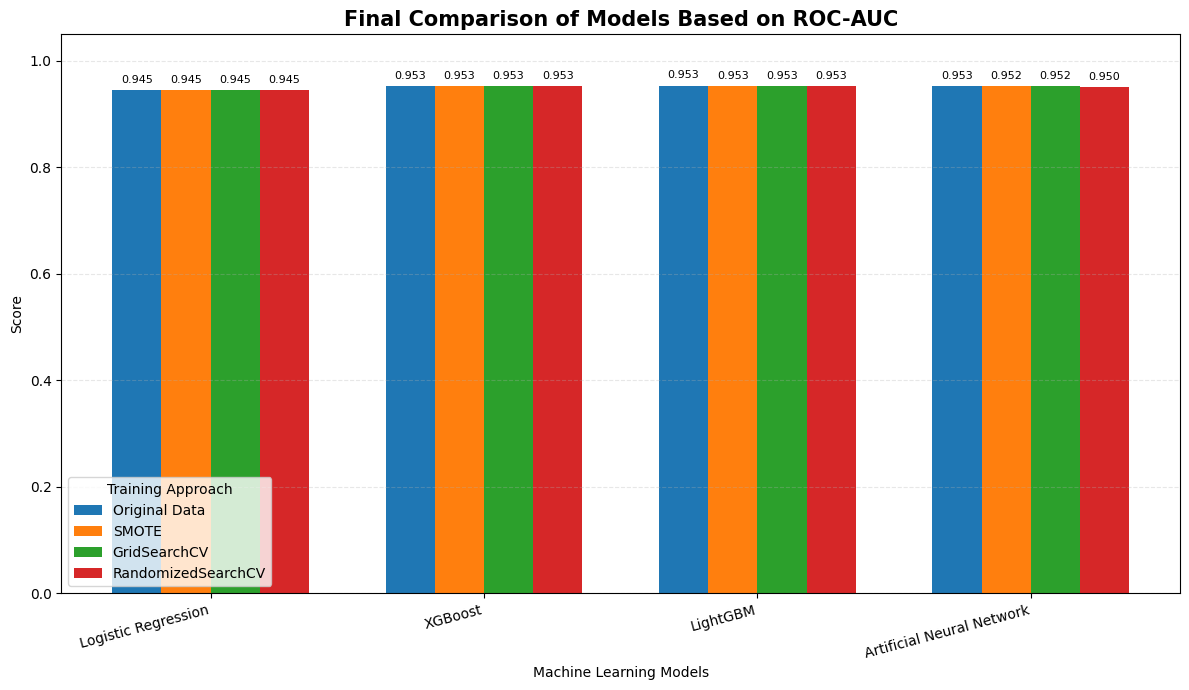

In [41]:
# I created separate graphs to compare the final model performance using each evaluation metric.

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

methods = [
    "Original Data",
    "SMOTE",
    "GridSearchCV",
    "RandomizedSearchCV"
]

models = [
    "Logistic Regression",
    "XGBoost",
    "LightGBM",
    "Artificial Neural Network"
]

for metric in metrics:

    plt.figure(figsize=(12, 7))

    x = np.arange(len(models))
    width = 0.18

    for i, method in enumerate(methods):

        method_data = final_comparison[
            final_comparison["Method"] == method
        ]

        values = []

        for model in models:
            model_data = method_data[
                method_data["Model"] == model
            ]

            if len(model_data) > 0:
                values.append(model_data[metric].iloc[0])
            else:
                values.append(0)

        bars = plt.bar(
            x + (i - 1.5) * width,
            values,
            width,
            label=method
        )

        for bar, value in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.01,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xticks(
        x,
        models,
        rotation=15,
        ha="right"
    )

    plt.xlabel("Machine Learning Models")
    plt.ylabel("Score")

    plt.title(
        f"Final Comparison of Models Based on {metric}",
        fontsize=15,
        fontweight="bold"
    )

    plt.ylim(0, 1.05)

    plt.legend(
        title="Training Approach"
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

#SHAP Analysis

SHAP Summary Plot


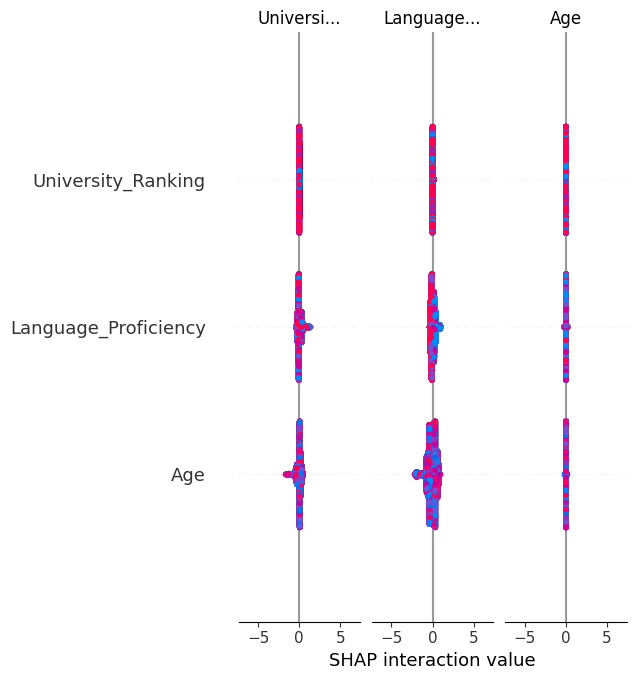

SHAP Feature Importance


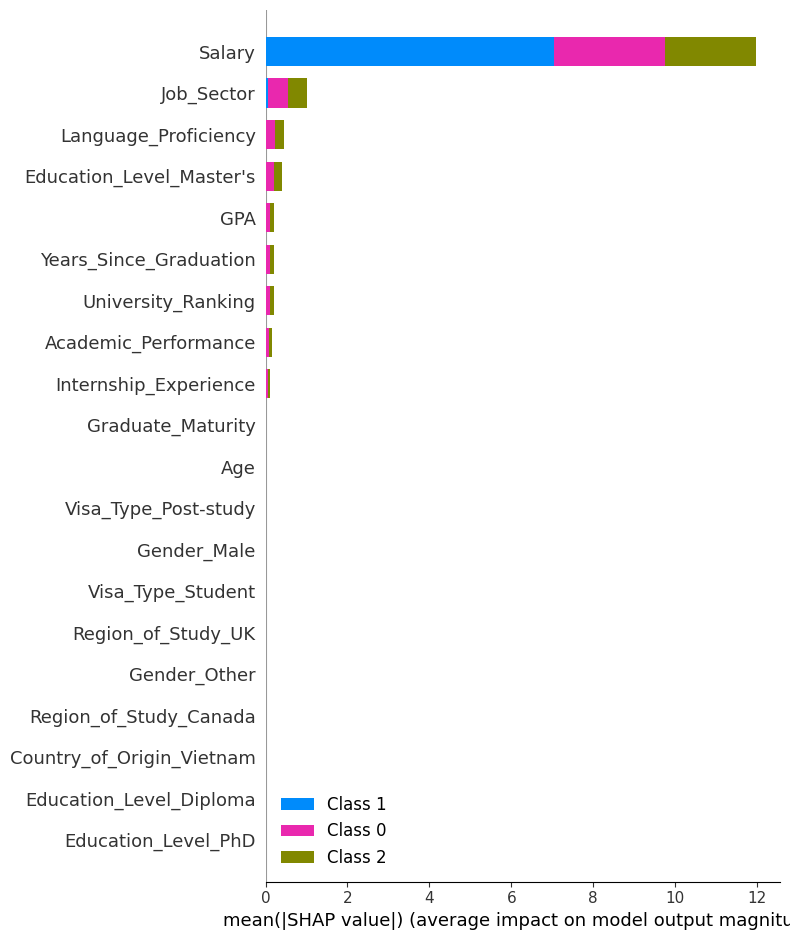

SHAP Waterfall Plot


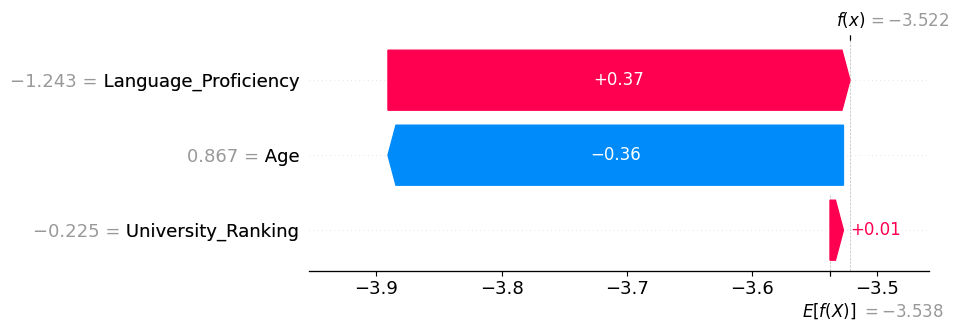

In [35]:
# I interpreted the final LightGBM model using SHAP.

explainer = shap.TreeExplainer(best_lgbm)

shap_values = explainer.shap_values(X_test_scaled)

# I displayed the SHAP summary plot.

print("SHAP Summary Plot")

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test_scaled.columns
)

# I displayed the SHAP feature importance plot.

print("SHAP Feature Importance")

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test_scaled.columns,
    plot_type="bar"
)

# I displayed the SHAP waterfall plot.

sample_index = 0

predicted_class = best_lgbm.predict(
    X_test_scaled.iloc[[sample_index]]
)[0]

print("SHAP Waterfall Plot")

try:

    shap.plots.waterfall(

        shap.Explanation(

            values=shap_values[predicted_class][sample_index],

            base_values=explainer.expected_value[predicted_class],

            data=X_test_scaled.iloc[sample_index],

            feature_names=X_test_scaled.columns

        )

    )

except Exception as error:

    print(error)

#Lime Analysis

LIME Feature Contributions


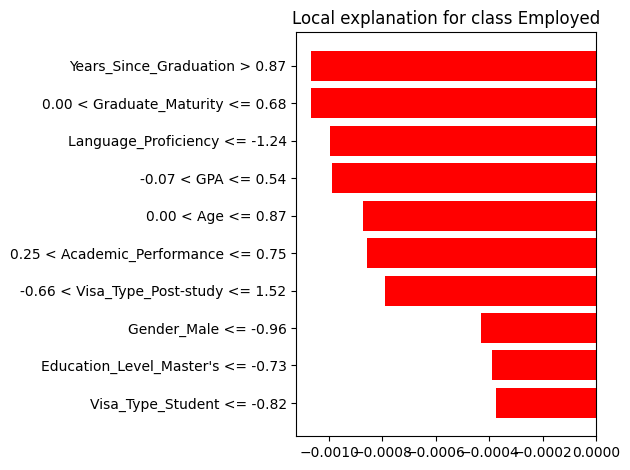

[('Years_Since_Graduation > 0.87', -0.0010687880180198217), ('0.00 < Graduate_Maturity <= 0.68', -0.00106863538584034), ('Language_Proficiency <= -1.24', -0.0009971447659773809), ('-0.07 < GPA <= 0.54', -0.0009888092835596077), ('0.00 < Age <= 0.87', -0.0008716839206621798), ('0.25 < Academic_Performance <= 0.75', -0.0008580639204210326), ('-0.66 < Visa_Type_Post-study <= 1.52', -0.0007907461749692004), ('Gender_Male <= -0.96', -0.0004290401994529146), ("Education_Level_Master's <= -0.73", -0.00038919475172590764), ('Visa_Type_Student <= -0.82', -0.0003737453517520523)]


In [36]:
# I interpreted the final LightGBM model using LIME.

from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=[str(cls) for cls in target_encoder.classes_],
    mode="classification"
)

sample_index = 0

lime_explanation = lime_explainer.explain_instance(
    X_test_scaled.iloc[sample_index].values,
    best_lgbm.predict_proba,
    num_features=10
)

print("LIME Feature Contributions")

fig = lime_explanation.as_pyplot_figure()

plt.tight_layout()

plt.show()

print(lime_explanation.as_list())

#Save the Final Model

In [37]:
# I saved the final model and preprocessing objects.

joblib.dump(best_lgbm, "best_lgbm.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(label_encoders, "label_encoders.pkl")

joblib.dump(target_encoder, "target_encoder.pkl")

joblib.dump(
    X_train.columns.tolist(),
    "feature_columns.pkl"
)

print("All model files were saved successfully.")

All model files were saved successfully.


#Prototype

In [38]:
# GRADUATE EMPLOYABILITY PREDICTION PROTOTYPE

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from datetime import datetime

# 1. Load the saved model and preprocessing objects

best_lgbm = joblib.load("best_lgbm.pkl")
scaler = joblib.load("scaler.pkl")
label_encoders = joblib.load("label_encoders.pkl")
target_encoder = joblib.load("target_encoder.pkl")
feature_columns = joblib.load("feature_columns.pkl")

try:
    raw_df = df.copy()
except NameError:
    raw_df = None

try:
    processed_df = df_processed.copy()
except NameError:
    processed_df = None


# 2. Helper functions

def dataset_values(column, fallback):
    if raw_df is not None and column in raw_df.columns:
        values = raw_df[column].dropna().astype(str).unique().tolist()
        return sorted(values)
    return fallback

def make_dropdown(options, value=None):
    options = list(options)
    if not options:
        options = ["Unknown"]
    if value is None or value not in options:
        value = options[0]
    return widgets.Dropdown(
        options=options,
        value=value,
        layout=widgets.Layout(width="100%", height="38px"),
        style={"description_width": "0px"}
    )

def get_encoder_classes(column, fallback):
    try:
        return [str(x) for x in label_encoders[column].classes_.tolist()]
    except Exception:
        return fallback

def esc(value):
    return (str(value)
            .replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
            .replace('"', "&quot;"))


# 3. Dataset-aware input options

country_options = dataset_values(
    "Country_of_Origin",
    ["Australia", "Brazil", "China", "Germany", "India", "Nigeria",
     "Pakistan", "USA", "Vietnam"]
)

education_options = dataset_values(
    "Education_Level",
    ["Bachelor's", "Diploma", "Master's", "PhD"]
)

field_options = dataset_values(
    "Field_of_Study",
    ["Arts", "Business", "Engineering", "Health", "IT", "Social Sciences"]
)

language_options = get_encoder_classes(
    "Language_Proficiency",
    ["Basic", "Intermediate", "Advanced", "Fluent"]
)

visa_options = dataset_values(
    "Visa_Type",
    ["None", "Post-study", "Student", "Work Visa", "Permanent Residency"]
)

gender_options = dataset_values(
    "Gender",
    ["Female", "Male", "Other"]
)

ranking_options = get_encoder_classes(
    "University_Ranking",
    ["High", "Medium", "Low"]
)

region_options = dataset_values(
    "Region_of_Study",
    ["Australia", "Canada", "EU", "UK", "USA"]
)

intern_options = get_encoder_classes(
    "Internship_Experience",
    ["No", "Yes"]
)

sector_options = get_encoder_classes(
    "Job_Sector",
    ["Finance", "Healthcare", "IT", "Other"]
)


# 4. Numeric ranges from the actual dataset

def numeric_range(column, default_min, default_max, default_value):
    if raw_df is not None and column in raw_df.columns:
        s = pd.to_numeric(raw_df[column], errors="coerce").dropna()
        if len(s):
            lo = float(s.min())
            hi = float(s.max())
            val = float(s.median())
            return lo, hi, val
    return float(default_min), float(default_max), float(default_value)

age_min, age_max, age_default = numeric_range("Age", 18, 60, 24)
ysg_min, ysg_max, ysg_default = numeric_range(
    "Years_Since_Graduation", 0, 20, 2
)
gpa_min, gpa_max, gpa_default = numeric_range("GPA", 0, 4, 3.2)
salary_min, salary_max, salary_default = numeric_range(
    "Salary", 0, 200000, 50000
)

age_min, age_max = int(np.floor(age_min)), int(np.ceil(age_max))
ysg_min, ysg_max = int(np.floor(ysg_min)), int(np.ceil(ysg_max))
gpa_min, gpa_max = max(0.0, gpa_min), min(4.0, gpa_max)


# 5. Input controls

country = make_dropdown(country_options, country_options[0])
education = make_dropdown(education_options, education_options[0])
field = make_dropdown(field_options, field_options[0])
language = make_dropdown(language_options, language_options[-1])
visa = make_dropdown(visa_options, visa_options[0])
gender = make_dropdown(gender_options, gender_options[0])
ranking = make_dropdown(ranking_options, ranking_options[0])
region = make_dropdown(region_options, region_options[0])
intern = make_dropdown(
    intern_options,
    "Yes" if "Yes" in intern_options else intern_options[0]
)
sector = make_dropdown(sector_options, sector_options[0])

age = widgets.IntSlider(
    value=int(round(age_default)),
    min=age_min, max=age_max, step=1,
    layout=widgets.Layout(width="100%", height="34px"),
    style={"description_width": "0px"},
    continuous_update=False
)

years = widgets.IntSlider(
    value=int(round(ysg_default)),
    min=ysg_min, max=ysg_max, step=1,
    layout=widgets.Layout(width="100%", height="34px"),
    style={"description_width": "0px"},
    continuous_update=False
)

gpa = widgets.FloatSlider(
    value=round(gpa_default, 2),
    min=gpa_min, max=gpa_max, step=0.01,
    readout_format=".2f",
    layout=widgets.Layout(width="100%", height="34px"),
    style={"description_width": "0px"},
    continuous_update=False
)

salary = widgets.IntText(
    value=int(round(salary_default)),
    layout=widgets.Layout(width="100%", height="38px"),
    style={"description_width": "0px"}
)

def field_card(label, control, hint=""):
    return widgets.VBox([
        widgets.HTML(
            f"<div class='field-label'>{esc(label)}</div>"
            + (f"<div class='field-hint'>{esc(hint)}</div>" if hint else "")
        ),
        control
    ], layout=widgets.Layout(width="100%", margin="0 0 10px 0"))

left_col = widgets.VBox([
    field_card("Country of Origin", country),
    field_card("Education Level", education),
    field_card("Field of Study", field),
    field_card("Language Proficiency", language),
    field_card("Visa Type", visa),
    field_card("Gender", gender),
    field_card("University Ranking", ranking)
], layout=widgets.Layout(width="48%", padding="4px 12px 4px 0"))

right_col = widgets.VBox([
    field_card("Region of Study", region),
    field_card("Age", age, f"{age_min}–{age_max} years"),
    field_card("Years Since Graduation", years),
    field_card("GPA", gpa, "0–4 scale"),
    field_card("Internship Experience", intern),
    field_card("Salary", salary, "Annual salary"),
    field_card("Job Sector", sector)
], layout=widgets.Layout(width="48%", padding="4px 0 4px 12px"))


# 6. Output areas

result_output = widgets.Output()
explanation_output = widgets.Output()
history_output = widgets.Output()
history_records = []

def result_placeholder():
    return widgets.HTML("""
    <div class="result-placeholder">
        <div class="placeholder-icon">◎</div>
        <div class="placeholder-title">Ready for Prediction</div>
        <div class="placeholder-text">
            Enter the graduate profile and click <b>Predict Employability</b>.
        </div>
    </div>
    """)


# 7. Preprocessing — follows the notebook pipeline

one_hot_columns = [
    "Country_of_Origin",
    "Education_Level",
    "Field_of_Study",
    "Visa_Type",
    "Gender",
    "Region_of_Study"
]

label_columns = [
    "Language_Proficiency",
    "University_Ranking",
    "Internship_Experience",
    "Job_Sector"
]

def prepare_input():
    row = {
        "Country_of_Origin": country.value,
        "Education_Level": education.value,
        "Field_of_Study": field.value,
        "Language_Proficiency": language.value,
        "Visa_Type": visa.value,
        "Gender": gender.value,
        "University_Ranking": ranking.value,
        "Region_of_Study": region.value,
        "Age": age.value,
        "Years_Since_Graduation": years.value,
        "GPA": gpa.value,
        "Internship_Experience": intern.value,
        "Salary": salary.value,
        "Job_Sector": sector.value
    }

    data = pd.DataFrame([row])

    # Same logarithmic Salary transformation used in the notebook.
    data["Salary"] = np.log1p(
        np.maximum(pd.to_numeric(data["Salary"], errors="coerce"), 0)
    )

    # Same engineered features used in the notebook.
    data["Academic_Performance"] = (
        data["GPA"] *
        (data["Internship_Experience"].map({"Yes": 1, "No": 0}) + 1)
    )

    data["Graduate_Maturity"] = (
        data["Age"] - data["Years_Since_Graduation"]
    )

    # Same label encoders saved by the notebook.
    for col in label_columns:
        encoder = label_encoders[col]
        value = str(data.loc[0, col])
        encoder_classes = [str(x) for x in encoder.classes_]

        if value not in encoder_classes:
            if col == "Job_Sector" and "Other" in encoder_classes:
                value = "Other"
            else:
                value = encoder_classes[0]

        data[col] = encoder.transform([value])

    # Same one-hot encoding used in training.
    data = pd.get_dummies(
        data,
        columns=one_hot_columns,
        drop_first=True,
        dtype=int
    )

    # Match exact training feature order.
    data = data.reindex(columns=feature_columns, fill_value=0)

    # Reproduce the notebook's IQR clipping when df_processed is available.
    if processed_df is not None:
        numeric_cols = [
            c for c in processed_df.select_dtypes(
                include=["int64", "float64"]
            ).columns
            if c != "Employment_Status" and c in data.columns
        ]

        for col in numeric_cols:
            q1 = processed_df[col].quantile(0.25)
            q3 = processed_df[col].quantile(0.75)
            iqr = q3 - q1
            data[col] = data[col].clip(
                lower=q1 - 1.5 * iqr,
                upper=q3 + 1.5 * iqr
            )

    scaled = pd.DataFrame(
        scaler.transform(data),
        columns=feature_columns
    )

    return data, scaled


# 8. SHAP local explanation

def get_local_shap_values(scaled_input, predicted_class):
    try:
        import shap

        local_explainer = shap.TreeExplainer(best_lgbm)
        values = local_explainer.shap_values(scaled_input)

        if isinstance(values, list):
            return np.asarray(values[predicted_class]).reshape(-1)

        values = np.asarray(values)

        if values.ndim == 3:
            if values.shape[0] == 1 and values.shape[2] > 1:
                return values[0, :, predicted_class]
            if values.shape[0] > 1 and values.shape[1] == 1:
                return values[predicted_class, 0, :]
            return values[0, :, predicted_class]

        if values.ndim == 2:
            return values[0]

    except Exception:
        pass

    return None


# 9. Prediction result renderer

def render_prediction(label, probabilities, confidence):
    label_lower = str(label).lower()

    if "employ" in label_lower and "unemploy" not in label_lower:
        badge_class = "employed"
        icon = "✓"
    elif "unemploy" in label_lower:
        badge_class = "unemployed"
        icon = "!"
    else:
        badge_class = "education"
        icon = "◆"

    probability_rows = ""

    for cls, prob in sorted(
        zip(target_encoder.classes_, probabilities),
        key=lambda x: x[1],
        reverse=True
    ):
        probability_rows += f"""
        <div class="prob-row">
            <div class="prob-top">
                <span>{esc(cls)}</span>
                <b>{prob:.1%}</b>
            </div>
            <div class="prob-track">
                <div class="prob-fill" style="width:{prob*100:.1f}%"></div>
            </div>
        </div>
        """

    return widgets.HTML(f"""
    <div class="prediction-card">
        <div class="result-small-title">PREDICTION RESULT</div>
        <div class="status-badge {badge_class}">
            <span class="status-icon">{icon}</span>
            <span>{esc(label)}</span>
        </div>

        <div class="confidence-area">
            <div class="confidence-label">Prediction Confidence</div>
            <div class="confidence-value">{confidence:.1%}</div>
            <div class="confidence-track">
                <div class="confidence-fill" style="width:{confidence*100:.1f}%"></div>
            </div>
        </div>

        <div class="prob-title">Class Probabilities</div>
        {probability_rows}
    </div>
    """)

# 10. SHAP renderer

def render_explanation(scaled_input, predicted_class, predicted_label):
    shap_values_local = get_local_shap_values(
        scaled_input, predicted_class
    )

    if shap_values_local is None:
        return widgets.HTML("""
        <div class="explain-card">
            <div class="section-mini-title">MODEL EXPLANATION</div>
            <div class="muted">Local SHAP explanation could not be generated.</div>
        </div>
        """)

    values = np.asarray(shap_values_local).reshape(-1)

    if len(values) != len(feature_columns):
        return widgets.HTML("""
        <div class="explain-card">
            <div class="section-mini-title">MODEL EXPLANATION</div>
            <div class="muted">SHAP output is not compatible with the current model format.</div>
        </div>
        """)

    temp = pd.DataFrame({
        "Feature": feature_columns,
        "SHAP": values
    })
    temp["Abs"] = temp["SHAP"].abs()
    temp = temp.sort_values("Abs", ascending=False).head(8)

    rows = ""
    for _, r in temp.iterrows():
        val = float(r["SHAP"])

        if val >= 0:
            direction = "supports"
            cls = "positive"
            symbol = "+"
        else:
            direction = "opposes"
            cls = "negative"
            symbol = "−"

        rows += f"""
        <div class="shap-row">
            <div class="shap-name">{esc(r["Feature"])}</div>
            <div class="shap-direction {cls}">
                {symbol} {abs(val):.3f} · {direction} prediction
            </div>
        </div>
        """

    return widgets.HTML(f"""
    <div class="explain-card">
        <div class="section-mini-title">MODEL EXPLANATION</div>
        <div class="explain-subtitle">
            Top factors influencing the <b>{esc(predicted_label)}</b> prediction
        </div>
        {rows}
        <div class="shap-note">
            SHAP values indicate how individual features contributed to this prediction.
        </div>
    </div>
    """)


# 11. Prediction history

def render_history():
    if not history_records:
        return widgets.HTML("""
        <div class="history-empty">
            No predictions yet. Your prediction history will appear here.
        </div>
        """)

    rows = ""

    for r in reversed(history_records[-8:]):
        rows += f"""
        <tr>
            <td>{esc(r["Time"])}</td>
            <td>{esc(r["Status"])}</td>
            <td>{r["Confidence"]:.1%}</td>
            <td>{esc(r["Country"])}</td>
            <td>{esc(r["Education"])}</td>
        </tr>
        """

    return widgets.HTML(f"""
    <div class="history-table-wrap">
        <table class="history-table">
            <thead>
                <tr>
                    <th>Time</th>
                    <th>Employment Status</th>
                    <th>Confidence</th>
                    <th>Country</th>
                    <th>Education</th>
                </tr>
            </thead>
            <tbody>{rows}</tbody>
        </table>
    </div>
    """)


# 12. Main prediction function

def predict(_=None):
    with result_output:
        clear_output(wait=True)

        try:
            original_input, scaled_input = prepare_input()

            prediction = best_lgbm.predict(scaled_input)[0]
            probabilities = best_lgbm.predict_proba(scaled_input)[0]

            predicted_label = target_encoder.inverse_transform(
                [prediction]
            )[0]

            confidence = float(np.max(probabilities))

            display(render_prediction(
                predicted_label,
                probabilities,
                confidence
            ))

            with explanation_output:
                clear_output(wait=True)
                display(render_explanation(
                    scaled_input,
                    int(prediction),
                    predicted_label
                ))

            history_records.append({
                "Time": datetime.now().strftime("%H:%M:%S"),
                "Status": str(predicted_label),
                "Confidence": confidence,
                "Country": country.value,
                "Education": education.value
            })

            with history_output:
                clear_output(wait=True)
                display(render_history())

            status_message.value = (
                "<span style='color:#18794e;font-weight:700;'>"
                "✓ Prediction completed successfully"
                "</span>"
            )

        except Exception as error:
            display(widgets.HTML(f"""
            <div class="error-card">
                <b>Prediction could not be generated.</b><br>
                {esc(error)}
            </div>
            """))

            status_message.value = (
                "<span style='color:#b42318;font-weight:700;'>"
                "Prediction error — please check the input values."
                "</span>"
            )


# 13. Clear / Exit

def clear_form(_=None):
    country.value = country_options[0]
    education.value = education_options[0]
    field.value = field_options[0]
    language.value = language_options[-1]
    visa.value = visa_options[0]
    gender.value = gender_options[0]
    ranking.value = ranking_options[0]
    region.value = region_options[0]
    age.value = int(round(age_default))
    years.value = int(round(ysg_default))
    gpa.value = round(gpa_default, 2)
    intern.value = "Yes" if "Yes" in intern_options else intern_options[0]
    salary.value = int(round(salary_default))
    sector.value = sector_options[0]

    with result_output:
        clear_output(wait=True)
        display(result_placeholder())

    with explanation_output:
        clear_output(wait=True)

    status_message.value = (
        "<span style='color:#667085;'>Form cleared.</span>"
    )

def exit_prototype(_=None):
    app_container.layout.display = "none"
    print("Prototype closed. Run the prototype cell again to reopen it.")


# 14. Buttons

predict_button = widgets.Button(
    description="  PREDICT EMPLOYABILITY",
    icon="check-circle",
    button_style="primary",
    layout=widgets.Layout(width="250px", height="46px")
)

clear_button = widgets.Button(
    description="  CLEAR",
    icon="refresh",
    layout=widgets.Layout(width="120px", height="46px")
)

exit_button = widgets.Button(
    description="  EXIT",
    icon="close",
    layout=widgets.Layout(width="100px", height="46px")
)

predict_button.on_click(predict)
clear_button.on_click(clear_form)
exit_button.on_click(exit_prototype)

status_message = widgets.HTML(
    "<span style='color:#667085;'>Enter the graduate details to begin.</span>"
)

# ------------------------------------------------------------
# 15. Complete visual design
# ------------------------------------------------------------
display(HTML("""
<style>

.grand-title {
    background: linear-gradient(135deg, #12395b, #1769aa);
    color: white;
    padding: 26px 30px;
    border-radius: 14px 14px 0 0;
    text-align: center;
    box-shadow: 0 4px 14px rgba(16, 42, 67, .15);
}

.grand-title h1 {
    margin: 0;
    font-size: 28px;
    font-weight: 800;
    letter-spacing: .3px;
}

.grand-title p {
    margin: 7px 0 0;
    font-size: 14px;
    opacity: .9;
}

.section-card {
    background: #ffffff;
    border: 1px solid #dfe6ee;
    border-radius: 12px;
    padding: 20px;
    box-shadow: 0 2px 10px rgba(16, 42, 67, .06);
}

.section-heading {
    font-size: 19px;
    font-weight: 800;
    color: #173b5f;
    margin-bottom: 14px;
    padding-bottom: 10px;
    border-bottom: 2px solid #e7eef5;
}

.section-heading span {
    color: #1f7ae0;
}

.field-label {
    color: #344054;
    font-size: 13px;
    font-weight: 700;
    margin-bottom: 4px;
}

.field-hint {
    color: #98a2b3;
    font-size: 10px;
    margin-bottom: 3px;
}

.result-placeholder {
    text-align: center;
    padding: 38px 20px;
    background: #f7faff;
    border: 1px dashed #b8cee4;
    border-radius: 12px;
}

.placeholder-icon {
    font-size: 40px;
    color: #2777c9;
}

.placeholder-title {
    color: #1769aa;
    font-size: 21px;
    font-weight: 800;
    margin-top: 5px;
}

.placeholder-text {
    color: #667085;
    font-size: 13px;
    margin-top: 6px;
}

.prediction-card {
    background: #ffffff;
    border: 1px solid #dce6ef;
    border-radius: 12px;
    padding: 22px;
}

.result-small-title {
    color: #667085;
    font-size: 12px;
    font-weight: 800;
    letter-spacing: 1.2px;
    text-align: center;
}

.status-badge {
    margin: 15px auto 20px;
    width: fit-content;
    min-width: 210px;
    padding: 13px 24px;
    border-radius: 30px;
    display: flex;
    align-items: center;
    justify-content: center;
    gap: 10px;
    font-size: 20px;
    font-weight: 800;
}

.status-icon {
    font-size: 21px;
}

.status-badge.employed {
    background: #e9f8ef;
    color: #167044;
    border: 1px solid #b7e4c7;
}

.status-badge.unemployed {
    background: #fff0f0;
    color: #b42318;
    border: 1px solid #f2b8b5;
}

.status-badge.education {
    background: #eef4ff;
    color: #2457a6;
    border: 1px solid #bfd2f2;
}

.confidence-area {
    text-align: center;
    margin: 12px 0 22px;
}

.confidence-label {
    color: #475467;
    font-size: 12px;
    font-weight: 700;
}

.confidence-value {
    color: #1769aa;
    font-size: 27px;
    font-weight: 850;
    margin: 3px 0 8px;
}

.confidence-track,
.prob-track {
    background: #e9eef4;
    height: 9px;
    border-radius: 10px;
    overflow: hidden;
}

.confidence-track {
    max-width: 360px;
    margin: auto;
}

.confidence-fill,
.prob-fill {
    height: 100%;
    background: linear-gradient(90deg, #1769aa, #35a7ff);
    border-radius: 10px;
}

.prob-title {
    color: #173b5f;
    font-weight: 800;
    font-size: 14px;
    margin-bottom: 12px;
}

.prob-row {
    margin-bottom: 12px;
}

.prob-top {
    display: flex;
    justify-content: space-between;
    color: #475467;
    font-size: 12px;
    margin-bottom: 5px;
}

.explain-card {
    background: #ffffff;
    border: 1px solid #dce6ef;
    border-radius: 12px;
    padding: 20px;
}

.section-mini-title {
    color: #1769aa;
    font-size: 12px;
    font-weight: 850;
    letter-spacing: 1px;
}

.explain-subtitle {
    color: #344054;
    font-size: 13px;
    margin: 7px 0 15px;
}

.shap-row {
    padding: 10px 0;
    border-bottom: 1px solid #edf1f5;
}

.shap-name {
    color: #344054;
    font-size: 12px;
    font-weight: 700;
}

.shap-direction {
    font-size: 11px;
    margin-top: 3px;
}

.shap-direction.positive {
    color: #16824a;
}

.shap-direction.negative {
    color: #b42318;
}

.shap-note {
    margin-top: 13px;
    padding: 9px 11px;
    background: #f6f8fa;
    border-radius: 7px;
    color: #667085;
    font-size: 10px;
}

.history-table-wrap {
    overflow-x: auto;
    border: 1px solid #dce6ef;
    border-radius: 10px;
}

.history-table {
    width: 100%;
    border-collapse: collapse;
    font-size: 12px;
}

.history-table th {
    background: #173b5f;
    color: white;
    padding: 10px;
    text-align: left;
}

.history-table td {
    padding: 9px 10px;
    border-bottom: 1px solid #edf1f5;
    color: #475467;
}

.history-empty {
    padding: 20px;
    text-align: center;
    color: #98a2b3;
    background: #fafbfc;
    border: 1px dashed #d0d5dd;
    border-radius: 10px;
    font-size: 12px;
}

.error-card {
    padding: 14px;
    background: #fff1f0;
    color: #b42318;
    border: 1px solid #f3c0bd;
    border-radius: 8px;
    font-size: 12px;
}

</style>
"""))

header = widgets.HTML("""
<div class="grand-title">
    <h1>GRADUATE EMPLOYABILITY PREDICTION</h1>
    <p>Explainable Machine Learning Decision Support Prototype</p>
</div>
""")

input_heading = widgets.HTML(
    "<div class='section-heading'><span>01</span> &nbsp; Graduate Information</div>"
)

result_heading = widgets.HTML(
    "<div class='section-heading'><span>02</span> &nbsp; Prediction Result</div>"
)

explain_heading = widgets.HTML(
    "<div class='section-heading'><span>03</span> &nbsp; Explainable AI Insights</div>"
)

history_heading = widgets.HTML(
    "<div class='section-heading'><span>04</span> &nbsp; Prediction History</div>"
)

input_card = widgets.VBox(
    [input_heading, widgets.HBox([left_col, right_col])],
    layout=widgets.Layout(
        width="100%",
        padding="20px",
        border="1px solid #dfe6ee",
        border_radius="12px"
    )
)

result_card = widgets.VBox(
    [result_heading, result_output],
    layout=widgets.Layout(
        width="100%",
        padding="20px",
        border="1px solid #dfe6ee",
        border_radius="12px"
    )
)

explain_card = widgets.VBox(
    [explain_heading, explanation_output],
    layout=widgets.Layout(
        width="100%",
        padding="20px",
        border="1px solid #dfe6ee",
        border_radius="12px"
    )
)

history_card = widgets.VBox(
    [history_heading, history_output],
    layout=widgets.Layout(
        width="100%",
        padding="20px",
        border="1px solid #dfe6ee",
        border_radius="12px"
    )
)

button_bar = widgets.HBox(
    [predict_button, clear_button, exit_button],
    layout=widgets.Layout(
        justify_content="center",
        gap="12px",
        margin="15px 0 8px 0"
    )
)

footer = widgets.HTML("""
<div style="
    text-align:center;
    color:#98a2b3;
    font-size:11px;
    padding:12px 0 4px;
">
    Graduate Employability Prediction • Explainable ML Research Prototype
</div>
""")

app_container = widgets.VBox(
    [
        header,

        widgets.HTML("<div style='height:12px'></div>"),

        # 01 - Graduate Information
        input_card,

        widgets.HTML("<div style='height:8px'></div>"),

        # ACTION BUTTONS
        button_bar,

        status_message,

        widgets.HTML("<div style='height:12px'></div>"),

        # 02 - Prediction Result
        result_card,

        widgets.HTML("<div style='height:12px'></div>"),

        # 03 - Explainable AI Insights
        explain_card,

        widgets.HTML("<div style='height:12px'></div>"),

        # 04 - Prediction History
        history_card,

        footer
    ],
    layout=widgets.Layout(
        width="100%",
        padding="10px",
        overflow="visible"
    )
)
with result_output:
    display(result_placeholder())

with history_output:
    display(render_history())

display(app_container)